In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage
from operator import add

In [2]:
class memory(TypedDict):
    chat: Annotated[list, add]

In [3]:
llm=ChatOllama(model="llama3.2:1b")

In [4]:
def chat_node(state:memory)->memory:
    prompt=state['chat']
    response=llm.invoke(prompt)
    return {"chat":[HumanMessage(content=state['chat']),AIMessage(content=response.content)]}

In [5]:
ms=InMemorySaver()

In [6]:
graph=StateGraph(memory)

In [7]:
graph.add_node("Chat_Bot",chat_node)
graph.add_edge(START,"Chat_Bot")
graph.add_edge("Chat_Bot",END)
workflow=graph.compile(checkpointer=ms)

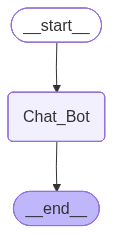

In [8]:
workflow

In [11]:
workflow.invoke({"chat": ["what is my name"]}, config={"thread_id": "3"})

{'chat': ['what is my name',
  HumanMessage(content=['what is my name'], additional_kwargs={}, response_metadata={}),
  AIMessage(content="I don't have any information about you. This is the beginning of our conversation, and I don't retain any information from previous conversations. I'm a large language model, I don't have the ability to store or recall your personal details. Each time you interact with me, it's a new conversation. If you'd like to tell me your name, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}